In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Data_Train_Feature_Engineered.csv')

### Step 1: Select Numeric columns

In [4]:
numeric_cols = [
    "Price",
    "Duration_Minutes",
    "Dep_Hour",
    "Dep_Minute",
    "Arrival_Hour",
    "Arrival_Minute",
    "Journey_Day",
    "Journey_Month",
    "Number_of_Airports"
]

### Step 2: Implement basic statistics

In [5]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,10682.0,9087.214567,4611.548810,1759.0,5277.0,8372.0,12373.0,79512.0
Duration_Minutes,10682.0,643.020502,507.830133,5.0,170.0,520.0,930.0,2860.0
Dep_Hour,10682.0,12.491013,5.748820,0.0,8.0,11.0,18.0,23.0
Dep_Minute,10682.0,24.409287,18.767801,0.0,5.0,25.0,40.0,55.0
Arrival_Hour,10682.0,13.349186,6.859317,0.0,8.0,14.0,19.0,23.0
Arrival_Minute,10682.0,24.690601,16.506808,0.0,10.0,25.0,35.0,55.0
Journey_Day,10682.0,13.509081,8.479363,1.0,6.0,12.0,21.0,27.0
Journey_Month,10682.0,4.708575,1.164408,3.0,3.0,5.0,6.0,6.0
Number_of_Airports,10682.0,2.824190,0.675229,2.0,2.0,3.0,3.0,6.0


### Step 4: Check the distribution

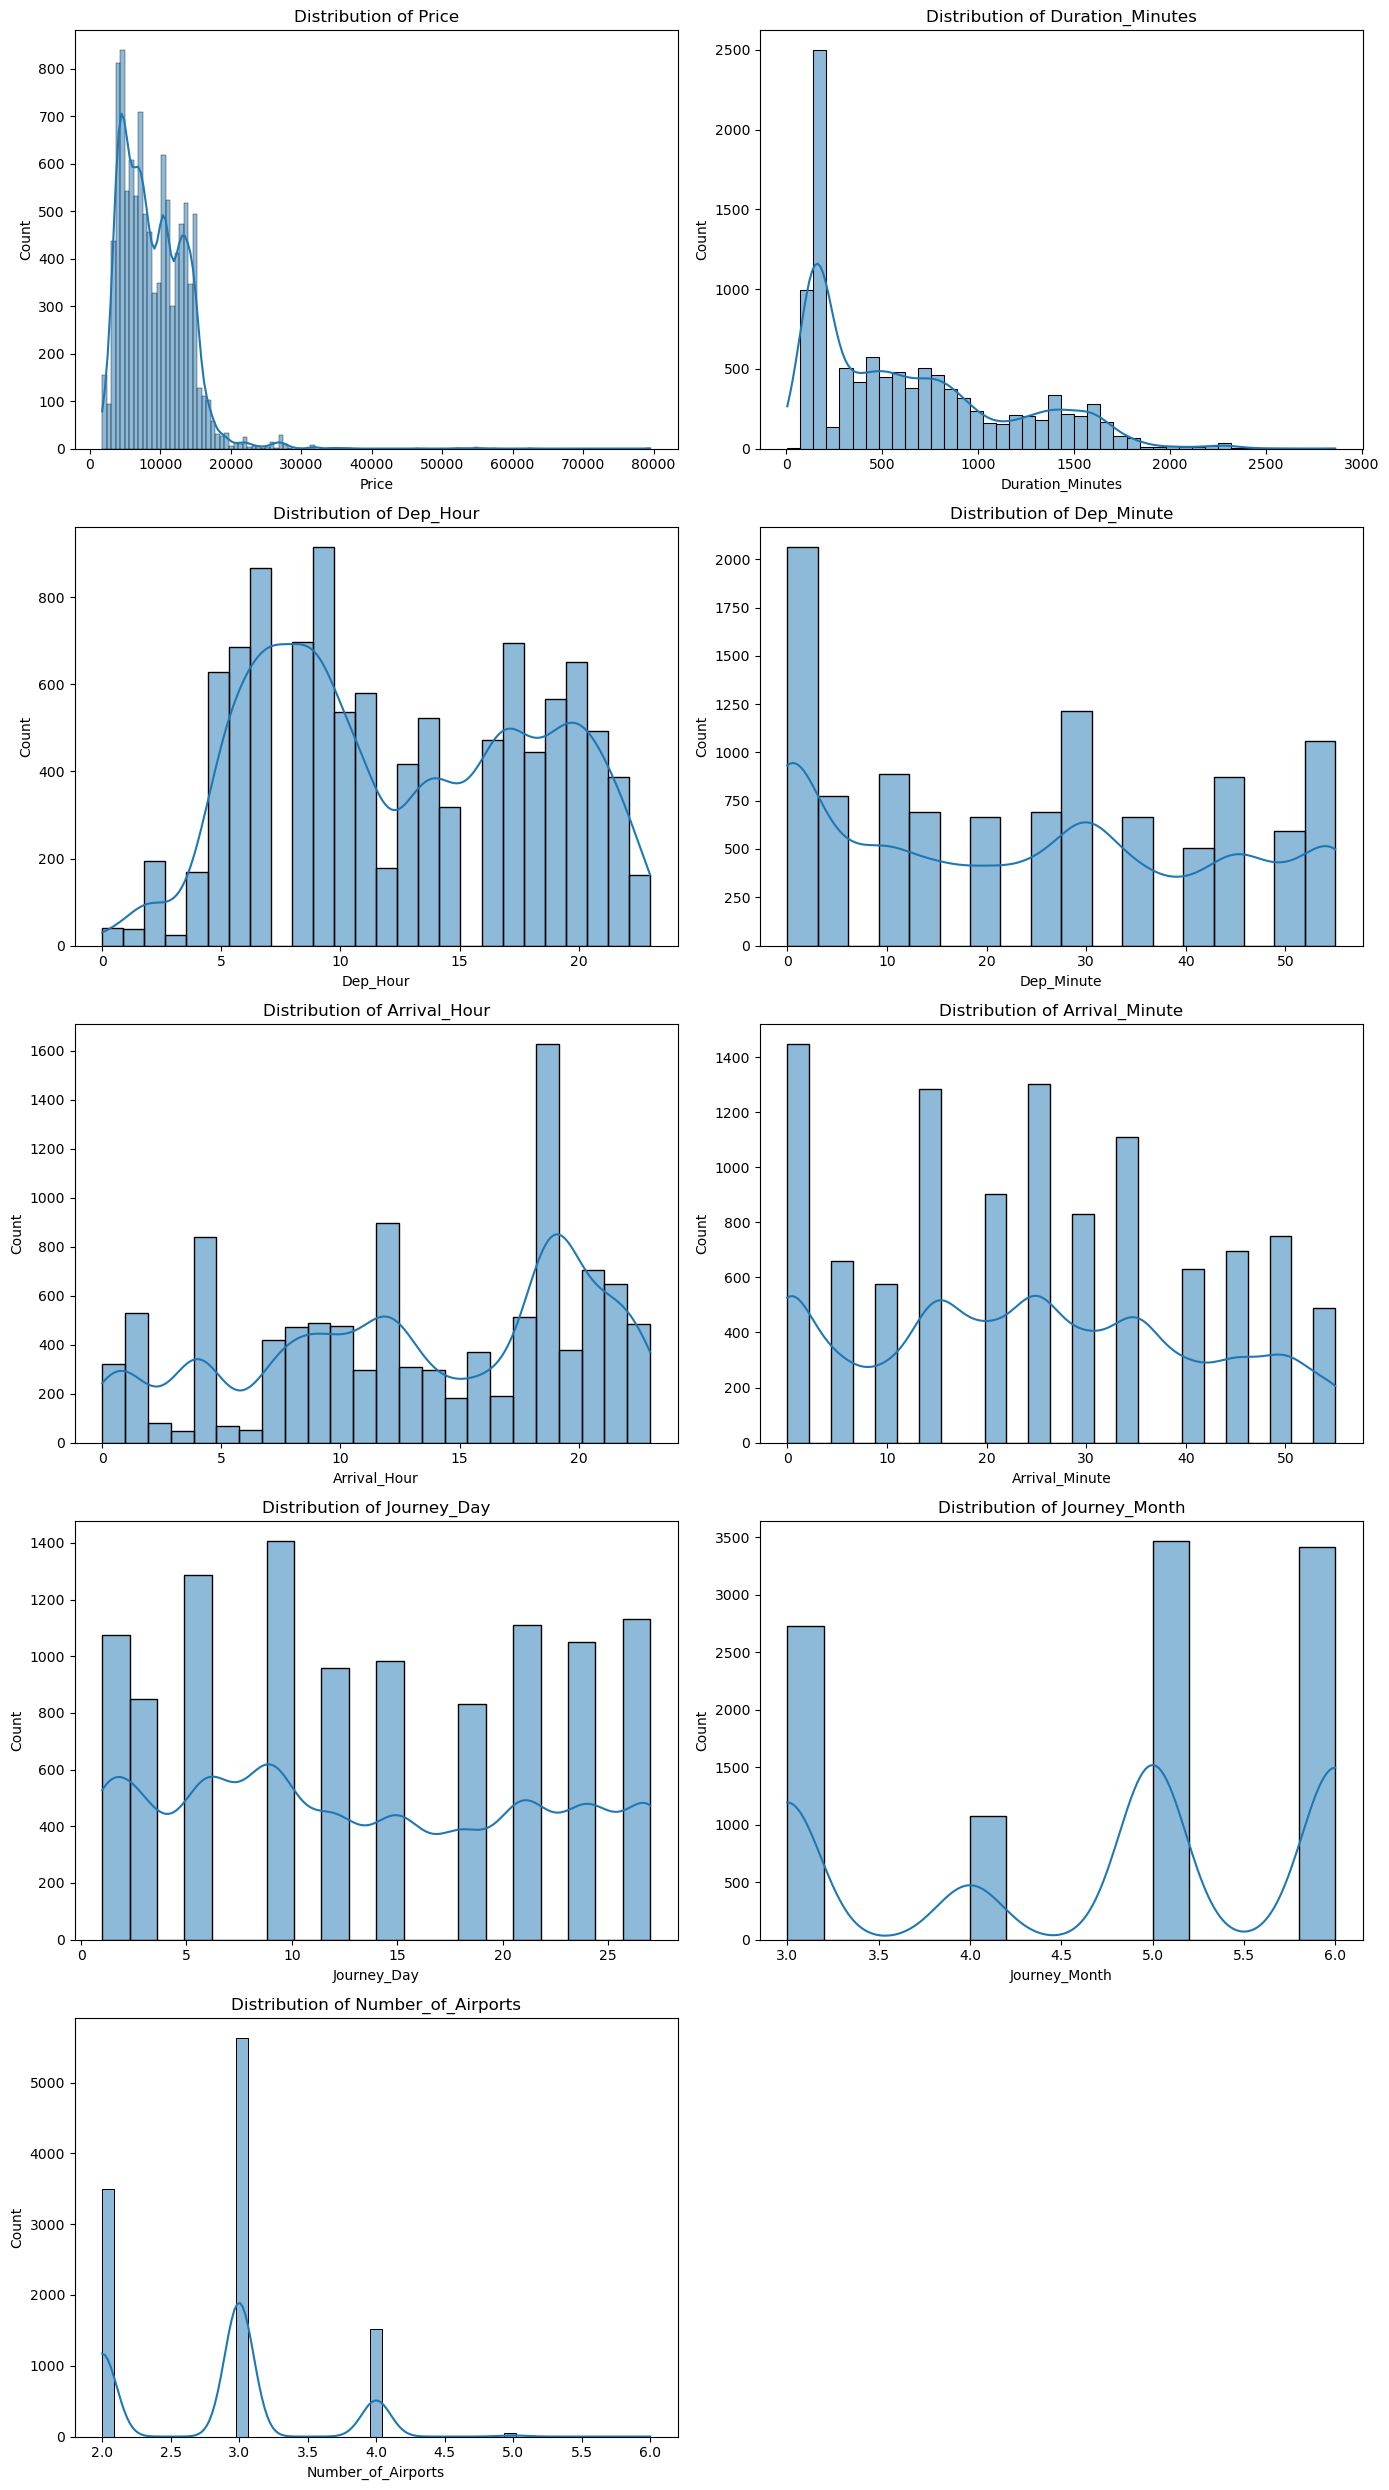

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 2                          # Number of plots per row
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()               # Convert 2D array of axes into 1D

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

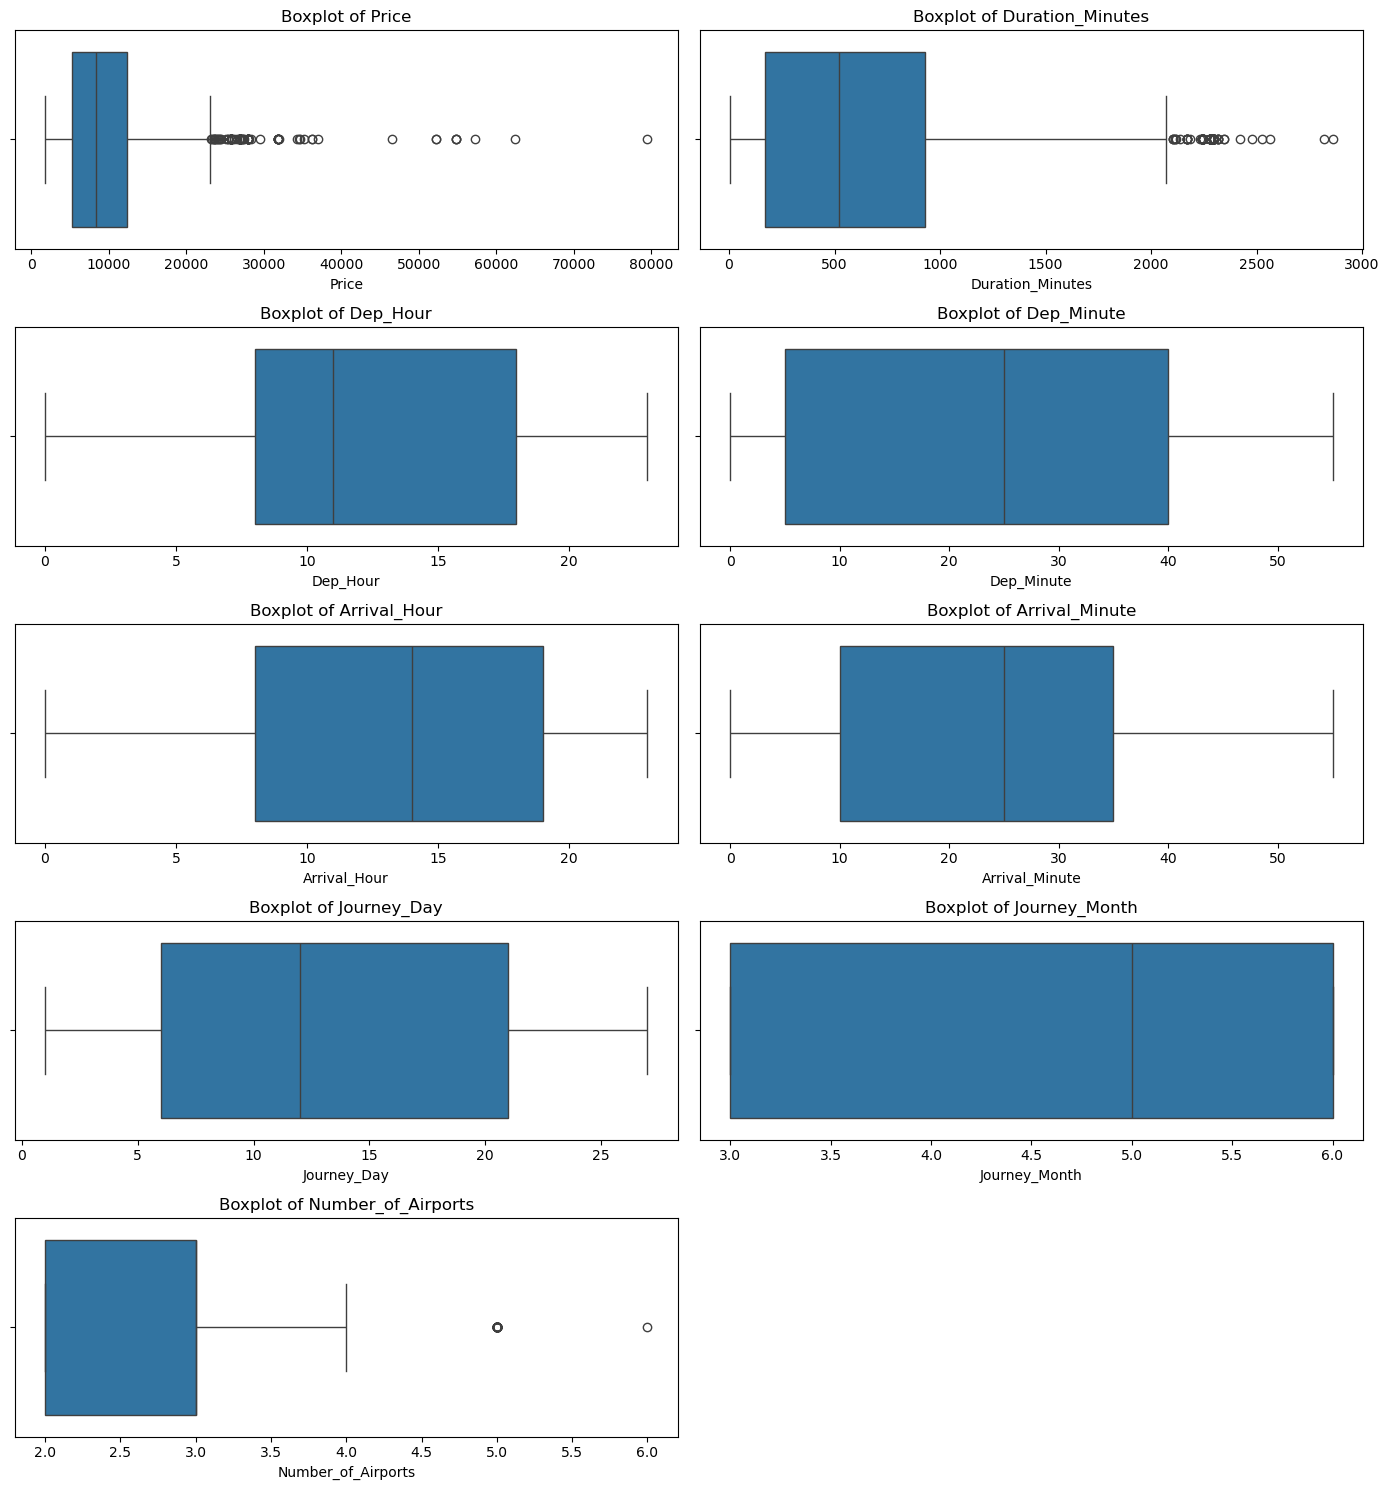

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Number of plots per row
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create subplots with a smaller height
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows))

# Flatten the axes array
axes = axes.flatten()

# Plot each boxplot
for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df[col], ax=axes[i])

    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing
plt.tight_layout()

# Display the figure
plt.show()

### Your outlier notebook should now focus only on:

1. ✅ Duration_Minutes
2. ✅ Price

Everything else can simply be documented as:

> "No outlier treatment was performed because these features have naturally bounded ranges or represent discrete counts."

#### ok, now, tell me how can i evaluate the price and duration minutes?

> This is where domain knowledge becomes more important than statistics. A boxplot can tell you which values are unusual, but it cannot tell you whether they are wrong.

## Evaluating Duration_Minutes
#### Step 1: Look at the longest flights

In [8]:
df.sort_values("Duration_Minutes", ascending=True)[[
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Total_Stops",
    "Duration_Minutes",
    "Price"
]].head()

,Airline,Source,Destination,Route,Total_Stops,Duration_Minutes,Price
6474,Air India,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,2,5,17327
10383,Air India,Mumbai,Hyderabad,BOM → HYD,0,75,3625
6573,Air India,Mumbai,Hyderabad,BOM → HYD,0,75,3100
2813,Air India,Mumbai,Hyderabad,BOM → HYD,0,75,3100
9449,Air India,Mumbai,Hyderabad,BOM → HYD,0,75,4307


#### Is this an outlier?

Absolutely.

A flight with:

- 2 stops
- 3 airports
- 5 minutes

is a classic data error, not merely an extreme observation.

##### What should you do?

Before training a model, inspect these suspicious rows:

In [9]:
df[df['Duration_Minutes'] < 30] [[
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Total_Stops",
    "Duration_Minutes",
    "Price"
]].sort_values('Duration_Minutes')

,Airline,Source,Destination,Route,Total_Stops,Duration_Minutes,Price
6474,Air India,Mumbai,Hyderabad,BOM → GOI → PNQ → HYD,2,5,17327


In [10]:
df.drop(index=6474, inplace=True)

In [11]:
df[["Duration_Minutes"]].describe()

,Duration_Minutes
count,10681.000000
mean,643.080236
std,507.816377
min,75.000000
25%,170.000000
50%,520.000000
75%,930.000000
max,2860.000000


In [12]:
df[df['Duration_Minutes'] > 2000 ] [[
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Total_Stops",
    "Duration_Minutes",
    "Price"
]].value_counts('Duration_Minutes')

Duration_Minutes
2280    13
2295    12
2240     8
2245     8
2170     6
2300     5
2315     4
2105     3
2070     2
2045     2
2065     2
2040     2
2115     2
2345     2
2135     1
2025     1
2120     1
2185     1
2230     1
2420     1
2480     1
2525     1
2565     1
2820     1
2860     1
Name: count, dtype: int64

#### Two ways of checking outliers.
> Between 2000 to 2500 and greater than 2500 and it should be based on stops coz, it is the only thing that could affect the time of the flight

### Method 1: Check flights between 2000 and 2500 minutes by stops

In [13]:
# Flights between 2000 and 2500 minutes
long_flights= (
    df[(df['Duration_Minutes'] >= 2000 ) & 
    (df['Duration_Minutes'] <= 2500 )]
    .sort_values(['Total_Stops','Duration_Minutes'])
)
long_flights[ [
        "Airline",
        "Source",
        "Destination",
        "Route",
        "Total_Stops",
        "Duration_Minutes",
        "Price"]
]

,Airline,Source,Destination,Route,Total_Stops,Duration_Minutes,Price
7445,Air India,Kolkata,Banglore,CCU → IXB → DEL → BLR,2,2000,15292
4615,Air India,Banglore,New Delhi,BLR → BOM → UDR → DEL,2,2025,10835
3152,Jet Airways,Delhi,Cochin,DEL → BDQ → BOM → COK,2,2040,12347
3856,Jet Airways,Delhi,Cochin,DEL → BDQ → BOM → COK,2,2040,12347
470,Jet Airways,Delhi,Cochin,DEL → UDR → BOM → COK,2,2045,13082
...,...,...,...,...,...,...,...
8153,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,3,2280,10703
8601,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,3,2280,10493
8729,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,3,2280,10493
9483,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,3,2280,9128


In [14]:

longer_flights = (
    df[df['Duration_Minutes'] > 2500]
    .sort_values(["Total_Stops", "Duration_Minutes"])
)

longer_flights[
    [
        "Airline",
        "Source",
        "Destination",
        "Route",
        "Total_Stops",
        "Duration_Minutes",
        "Price"
    ]
]


,Airline,Source,Destination,Route,Total_Stops,Duration_Minutes,Price
5953,Jet Airways,Delhi,Cochin,DEL → IDR → BOM → COK,2,2525,11664
8409,Jet Airways,Delhi,Cochin,DEL → JAI → BOM → COK,2,2565,12819
1067,Jet Airways,Delhi,Cochin,DEL → IDR → BOM → COK,2,2820,20064
10455,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,2,2860,20694


In [15]:
df[df["Duration_Minutes"] > 2500].shape

(4, 17)

In [16]:
for stop in sorted(df["Total_Stops"].unique()):
    print(f"\n===== {stop} Stops =====")
    
    display(
        df[df["Total_Stops"] == stop]
        .sort_values("Duration_Minutes", ascending=False)
        .head(10)[
            [
                "Airline",
                "Source",
                "Destination",
                "Route",
                "Duration_Minutes",
                "Price"
            ]
        ]
    )


===== 0 Stops =====


,Airline,Source,Destination,Route,Duration_Minutes,Price
6454,Air India,Delhi,Cochin,DEL → COK,230,5201
6347,Air India,Delhi,Cochin,DEL → COK,230,6094
8013,Air India,Delhi,Cochin,DEL → COK,230,6724
50,Jet Airways,Delhi,Cochin,DEL → COK,195,7202
6827,IndiGo,Delhi,Cochin,DEL → COK,195,6834
1486,IndiGo,Delhi,Cochin,DEL → COK,195,6015
10454,IndiGo,Delhi,Cochin,DEL → COK,195,6015
9093,IndiGo,Delhi,Cochin,DEL → COK,195,5601
10493,IndiGo,Delhi,Cochin,DEL → COK,195,5000
6728,IndiGo,Delhi,Cochin,DEL → COK,195,5601



===== 1 Stops =====


,Airline,Source,Destination,Route,Duration_Minutes,Price
3133,Vistara,Kolkata,Banglore,CCU → DEL → BLR,1750,12102
4570,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,14151
6804,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,13067
4959,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,12692
3105,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,14151
8076,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,13067
3333,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,10539
2646,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1745,11467
3498,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1730,10703
1937,Jet Airways,Kolkata,Banglore,CCU → DEL → BLR,1730,11467



===== 2 Stops =====


,Airline,Source,Destination,Route,Duration_Minutes,Price
10455,Jet Airways,Delhi,Cochin,DEL → AMD → BOM → COK,2860,20694
1067,Jet Airways,Delhi,Cochin,DEL → IDR → BOM → COK,2820,20064
8409,Jet Airways,Delhi,Cochin,DEL → JAI → BOM → COK,2565,12819
5953,Jet Airways,Delhi,Cochin,DEL → IDR → BOM → COK,2525,11664
7906,Air India,Kolkata,Banglore,CCU → GAU → DEL → BLR,2480,13990
10325,Air India,Banglore,New Delhi,BLR → CCU → GAU → DEL,2420,11791
6321,Air India,Banglore,New Delhi,BLR → BOM → AMD → DEL,2345,17135
9847,Air India,Banglore,New Delhi,BLR → BOM → AMD → DEL,2345,17135
7612,Air India,Banglore,New Delhi,BLR → BOM → BHO → DEL,2315,10783
5701,Air India,Banglore,New Delhi,BLR → BOM → BHO → DEL,2315,25430



===== 3 Stops =====


,Airline,Source,Destination,Route,Duration_Minutes,Price
2172,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10703
2718,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,15586
9483,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,9128
8729,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10493
10638,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10493
6884,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10703
8153,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10703
7876,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10703
8601,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10493
4118,Air India,Delhi,Cochin,DEL → RPR → NAG → BOM → COK,2280,10703



===== 4 Stops =====


,Airline,Source,Destination,Route,Duration_Minutes,Price
9181,Air India,Banglore,New Delhi,BLR → CCU → BBI → HYD → VGA → DEL,1770,17686


In [17]:
# Compare average duration by number of stops
df.groupby("Total_Stops")["Duration_Minutes"].agg(["count", "mean", "median", "max", 'min'])

,count,mean,median,max,min
Total_Stops,,,,,
0,3491,150.084503,160.0,230,75
1,5625,781.940444,705.0,1750,195
2,1519,1234.348255,1275.0,2860,150
3,45,1547.444444,1585.0,2280,565
4,1,1770.000000,1770.0,1770,1770


In [18]:
df.drop(index=9181, inplace=True)

In [19]:
df.shape

(10680, 17)

### **Conclusion:** Handling Outliers in `Duration_Minutes`

The `Duration_Minute`s feature was examined for anomalous values by analyzing flight durations within each `Total_Stops` category. Since the number of stops naturally affects the overall journey time, outlier detection was performed with this context in mind rather than using a single global threshold.

**During the analysis:**

- An impossible flight with a duration of 5 minutes (Mumbai → Hyderabad) was identified and removed, as it was clearly a data entry error.
- A 4-stop flight with an unusually long duration was also removed because it was an isolated observation within its category and did not represent a typical flight pattern.
- Other long-duration flights (such as journeys lasting around 47 hours) were retained. Although uncommon, these flights are still realistic because total journey duration includes layover time, making them valid observations rather than data errors.

**Summary:**

- Initial focus: `Duration_Minutes`
- Context used: `Total_Stops`
- Rows removed: 2
- Reason: Only observations that were clearly erroneous or highly inconsistent with their respective groups were removed.
- Remaining long-duration flights were preserved because they are operationally possible and may contain meaningful information for predicting ticket prices.

# The Price Column

## Step 1: Basic statistics

In [20]:
df[['Price']].describe()

,Price
count,10680.000000
mean,9085.637921
std,4610.540237
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Step 2: Distribution

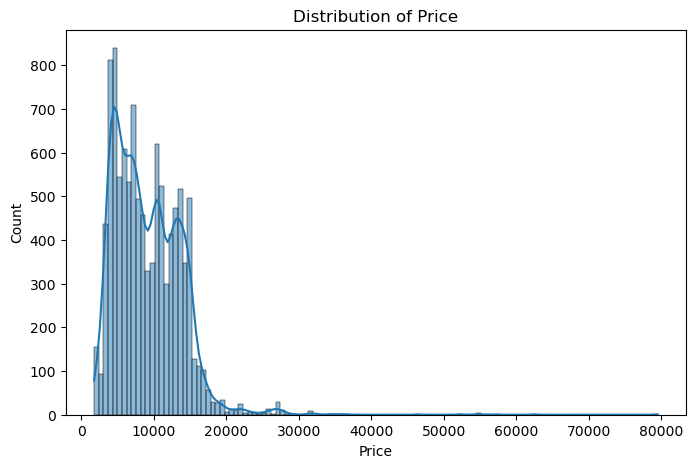

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='Price' ,kde=True)
plt.title("Distribution of Price")
plt.show()

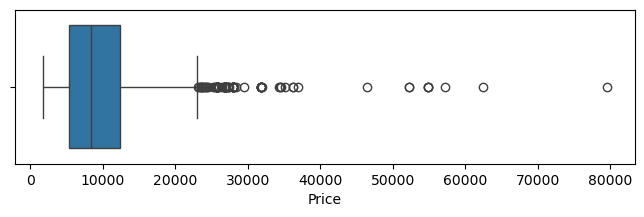

In [22]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Price"])
plt.show()

In [23]:
df[df['Price'] > 30000][['Airline','Total_Stops']].value_counts()

Airline               Total_Stops
Jet Airways           1              12
Jet Airways Business  1               4
                      2               2
Multiple carriers     1               2
                      2               2
Air India             2               1
                      0               1
Name: count, dtype: int64

## From the plots, here's what I observe:

**Distribution**
- Strong right-skewed distribution.
- Most ticket prices lie roughly between ₹3,000 and ₹18,000.
- Very few tickets extend beyond ₹20,000, with some reaching nearly ₹80,000.

**Boxplot**
- The IQR method flags many observations as outliers.
- That doesn't automatically mean they're bad data. It simply means they're far from the middle 50%.

#### Now comes the detective work

If airline and stops don't explain those expensive tickets, investigate the remaining important features.

### 1. Duration ⭐ (Most likely)

Longer flights generally cost more.

In [24]:
df[df['Price'] > 20000][['Price','Duration_Minutes']].sort_values('Price')

,Price,Duration_Minutes
1067,20064,2820
9246,20064,2245
2800,20120,405
4648,20416,1490
4142,20694,1995
...,...,...
5439,54826,365
2618,54826,375
10363,57209,280
5372,62427,400


<Axes: xlabel='Duration_Minutes', ylabel='Price'>

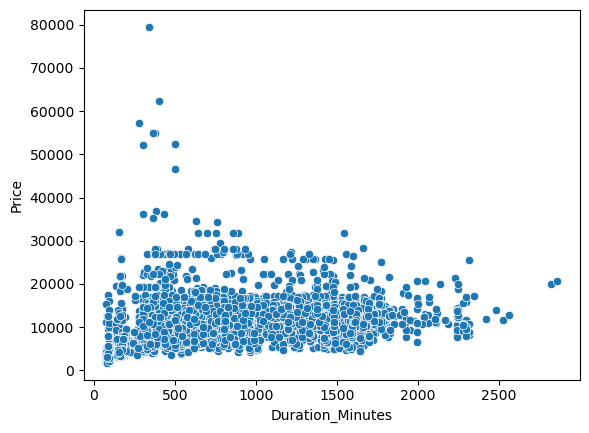

In [25]:
sns.scatterplot(data=df, x='Duration_Minutes', y='Price')

About those 148 observations above ₹20,000

This is where our investigation should focus.

Ask:

> What makes these flights expensive?

**Possible factors include:**

- ✅ Airline (Vistara Business, Jet Airways Business, etc.)
- ✅ Additional information (Business class, premium services)
- ✅ Route (some routes are naturally expensive)
- ✅ Total Stops
- ✅ Source and Destination combinations
- ✅ Seasonality (Journey date/month)

Notice that we've already checked Airline and Stops and didn't find a clear explanation. That's perfectly normal. Price is often influenced by multiple variables together, not one variable in isolation.

#### what should we do next?

Filter only the expensive flights.

In [26]:
high_price = df[df['Price'] > 20000]
high_price.shape

(148, 17)

In [27]:
high_price["Route"].value_counts().head(20)

Route
BLR → BOM → DEL                81
DEL → BOM → COK                10
DEL → IDR → BOM → COK           5
BLR → DEL                       5
DEL → JDH → BOM → COK           4
BLR → BOM → BHO → DEL           4
BOM → JDH → DEL → HYD           3
DEL → ATQ → BOM → COK           3
DEL → AMD → BOM → COK           3
BOM → DEL → HYD                 2
DEL → IXU → BOM → COK           2
BOM → BDQ → DEL → HYD           2
BLR → MAA → DEL                 2
DEL → GWL → IDR → BOM → COK     2
DEL → CCU → BOM → COK           2
DEL → UDR → BOM → COK           2
DEL → BLR → COK                 2
BLR → BOM → NAG → DEL           1
DEL → GOI → BOM → COK           1
BOM → DED → DEL → HYD           1
Name: count, dtype: int64

In [28]:
print(high_price["Source"].value_counts())

Source
Banglore    98
Delhi       38
Mumbai      11
Kolkata      1
Name: count, dtype: int64


In [29]:
print(high_price["Destination"].value_counts())

Destination
New Delhi    98
Cochin       38
Hyderabad    11
Banglore      1
Name: count, dtype: int64


In [30]:
print(high_price["Airline"].value_counts())

Airline
Jet Airways             99
Air India               23
Multiple carriers       14
Jet Airways Business     6
Vistara                  3
SpiceJet                 1
IndiGo                   1
GoAir                    1
Name: count, dtype: int64


In [31]:
high_price[high_price["Route"] == "BLR → BOM → DEL"][['Airline','Source','Destination','Price']].value_counts()

Airline               Source    Destination  Price
Jet Airways           Banglore  New Delhi    26890    24
                                             22270    13
                                             25735    10
                                             27992     9
                                             31825     6
                                             20800     4
                                             54826     3
                                             21934     2
                                             27210     2
                                             36235     2
IndiGo                Banglore  New Delhi    22153     1
Air India             Banglore  New Delhi    23677     1
Jet Airways           Banglore  New Delhi    35185     1
Jet Airways Business  Banglore  New Delhi    52229     1
                                             62427     1
                                             79512     1
Name: count, dtype: int64

In [32]:
high_price[high_price["Route"] == "DEL → BOM → COK"][['Airline','Source','Destination','Price']].value_counts()

Airline            Source  Destination  Price
Air India          Delhi   Cochin       27430    1
                                        28322    1
GoAir              Delhi   Cochin       22794    1
Multiple carriers  Delhi   Cochin       21226    1
                                        23170    1
                                        23533    1
                                        24318    1
                                        29528    1
                                        34273    1
                                        36983    1
Name: count, dtype: int64

In [33]:
high_price[high_price["Route"] == "BLR → BOM → DEL"][['Airline','Source','Destination','Price','Duration_Minutes','Total_Stops']]

,Airline,Source,Destination,Price,Duration_Minutes,Total_Stops
7,Jet Airways,Banglore,New Delhi,22270,1265,1
486,Jet Airways,Banglore,New Delhi,26890,380,1
510,Jet Airways,Banglore,New Delhi,26890,325,1
628,Jet Airways,Banglore,New Delhi,27210,370,1
657,Jet Airways Business,Banglore,New Delhi,52229,300,1
...,...,...,...,...,...,...
10181,Air India,Banglore,New Delhi,23677,330,1
10188,Jet Airways,Banglore,New Delhi,27992,800,1
10382,Jet Airways,Banglore,New Delhi,26890,1325,1
10438,Jet Airways,Banglore,New Delhi,31825,860,1


In [34]:
df["Journey_Quarter"] = ((df["Journey_Month"] - 1) // 3) + 1

In [35]:
high_price["Journey_Quarter"] = ((df["Journey_Month"] - 1) // 3) + 1
high_price["Journey_Quarter"].value_counts()

C:\Users\dhara\AppData\Local\Temp\ipykernel_26708\2442626264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_price["Journey_Quarter"] = ((df["Journey_Month"] - 1) // 3) + 1


Journey_Quarter
1    144
2      4
Name: count, dtype: int64

In [36]:
pd.crosstab(
    high_price["Journey_Quarter"],
    high_price["Price"] > 20000

) 

Price,True
Journey_Quarter,
1,144
2,4


In [37]:
df[df["Price"] > 30000]["Route"].value_counts()

Route
BLR → BOM → DEL          15
DEL → BOM → COK           2
DEL → ATQ → BOM → COK     2
DEL → IDR → BOM → COK     2
BLR → BOM → NAG → DEL     1
CCU → BLR                 1
BLR → MAA → DEL           1
Name: count, dtype: int64

In [38]:
(
    df[df["Price"] > 30000]
    .groupby(["Journey_Quarter", "Route"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

Journey_Quarter  Route                
1                BLR → BOM → DEL          15
                 DEL → ATQ → BOM → COK     2
                 DEL → IDR → BOM → COK     2
                 BLR → BOM → NAG → DEL     1
                 CCU → BLR                 1
                 BLR → MAA → DEL           1
                 DEL → BOM → COK           1
2                DEL → BOM → COK           1
dtype: int64

In [39]:
high_price.groupby("Journey_Quarter")["Route"].value_counts()

Journey_Quarter  Route                      
1                BLR → BOM → DEL                81
                 DEL → BOM → COK                 9
                 BLR → DEL                       5
                 DEL → IDR → BOM → COK           5
                 BLR → BOM → BHO → DEL           4
                 BOM → JDH → DEL → HYD           3
                 DEL → AMD → BOM → COK           3
                 DEL → ATQ → BOM → COK           3
                 BLR → MAA → DEL                 2
                 BOM → BDQ → DEL → HYD           2
                 BOM → DEL → HYD                 2
                 DEL → BLR → COK                 2
                 DEL → CCU → BOM → COK           2
                 DEL → GWL → IDR → BOM → COK     2
                 DEL → IXU → BOM → COK           2
                 DEL → UDR → BOM → COK           2
                 BLR → BDQ → DEL                 1
                 BLR → BOM → IDR → DEL           1
                 BLR → BOM → JDH → DE

In [40]:
high_price["Route"].value_counts(normalize=True).head(10) * 100

Route
BLR → BOM → DEL          54.729730
DEL → BOM → COK           6.756757
DEL → IDR → BOM → COK     3.378378
BLR → DEL                 3.378378
DEL → JDH → BOM → COK     2.702703
BLR → BOM → BHO → DEL     2.702703
BOM → JDH → DEL → HYD     2.027027
DEL → ATQ → BOM → COK     2.027027
DEL → AMD → BOM → COK     2.027027
BOM → DEL → HYD           1.351351
Name: proportion, dtype: float64

> The analysis shows that premium-priced tickets are highly concentrated in Journey Quarter 1, indicating a strong seasonal demand effect. Furthermore, more than half of these premium fares occur on the BLR → BOM → DEL route, suggesting that the combination of travel season and this specific route is the primary driver of extremely high ticket prices. Other airlines and the number of stops do not exhibit a comparable influence.

> "Outlier analysis identified two erroneous observations in the `Duration_Minutes` feature, which were removed. Although the `Price` feature contained extreme values, further investigation showed that these were legitimate observations associated with Quarter 1 travel and specific routes, particularly `BLR → BOM → DEL`. Therefore, the high-priced observations were retained."

In [43]:
df.to_csv('Data_Train_Outliers_Removed.csv', index=False)